# Make figures for the SCA comparison

In [1]:
import os
from glob import glob
import xarray as xr
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from tqdm import tqdm
import seaborn as sns

plt.rcParams.update({'font.size': 12, 'font.sans-serif': 'Verdana'})

base_dir = "/Users/rdcrlrka/Research/SIRO/MCS_SCA/"
out_dir = os.path.join(base_dir, "SCA_comparison_results")
fig_dir = os.path.join(base_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)

# Locate files
files_dict = {
    "PSS": {
        "mosaic_files": sorted(glob(os.path.join(base_dir, "PSS_image_mosaics_clipped", "*.tif"))),
        "SCA_files": sorted(glob(os.path.join(base_dir, "PSS_SCA", "*.tif"))),
        "SCA_regrid_files": sorted(glob(os.path.join(out_dir, "PlanetScope*.nc"))),
        "color": "#332288",
        "shape": "*"
    },
    "HMS-EB": {
        "SCA_files": sorted(glob(os.path.join(base_dir, "model_SCA", "HMS-EB*.nc"))),
        "color": "#882255",
        "shape": "o"
    },
    "HMS-TI": {
        "SCA_files": sorted(glob(os.path.join(base_dir, "model_SCA", "HMS-TI*.nc"))),
        "color": "#CC6677",
        "shape": "s"
    },
    "iSnobal": {
        "SCA_files": sorted(glob(os.path.join(base_dir, "model_SCA", "iSnobal*.nc"))),
        "color": "#88CCEE",
        "shape": "^"
    },
    "SnowModel": {
        "SCA_files": sorted(glob(os.path.join(base_dir, "model_SCA", "SnowModel*.nc"))),
        "color": "#117733",
        "shape": "h"
    }
}

print("Located files:")
for key in files_dict.keys():
    print(key)
    for sub_key in files_dict[key].keys():
        print(f"\t{sub_key}:", len(files_dict[key][sub_key]))



Located files:
PSS
	mosaic_files: 107
	SCA_files: 107
	SCA_regrid_files: 3
	color: 7
	shape: 1
HMS-EB
	SCA_files: 12
	color: 7
	shape: 1
HMS-TI
	SCA_files: 12
	color: 7
	shape: 1
iSnobal
	SCA_files: 6
	color: 7
	shape: 1
SnowModel
	SCA_files: 12
	color: 7
	shape: 1


## Define some color palettes

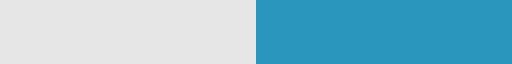

In [2]:
sca_cmap = matplotlib.colors.ListedColormap(["#e7e6e6", "#2A96BD"])
sca_cmap

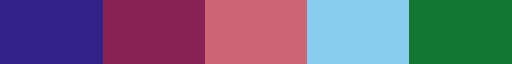

In [3]:
ds_colors = [files_dict[key]["color"] for key in files_dict.keys()]
ds_cmap = matplotlib.colors.ListedColormap(ds_colors)
ds_cmap


## Map timeseries GIF

In [ ]:
# Load SCA totals timeseries
sca_total_file = os.path.join(fig_dir, "SCA_totals_timeseries_compiled_Task1.csv")
sca_total_df = pd.read_csv(sca_total_file, index_col=0)
sca_total_df.index = pd.DatetimeIndex(sca_total_df.index)

fig, ax = plt.subplots(figsize=(15, 7))
# models
for ds in ["PSS", "HMS-EB", "HMS-TI", "iSnobal", "SnowModel"]:
    ax.fill_between(
        sca_total_df.index, np.divide(sca_total_df[f'{ds}_SCA_min_m2'], 1e6), np.divide(sca_total_df[f'{ds}_SCA_max_m2'], 1e6),
        color=files_dict[ds]["color"], label=ds + " range", alpha=0.4
    )
    ax.plot(
        sca_total_df.index, np.divide(sca_total_df[f'{ds}_SCA_mean_m2'], 1e6), '-',
        color=files_dict[ds]["color"], label=ds
    )

ax.set_xlabel("Date")
ax.set_ylabel("Snow-Covered Area (km$^2$)")
ax.legend(loc='right', bbox_to_anchor=[1.1, 0.4, 0.2, 0.2])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
gif_out_dir = os.path.join(out_dir, "SCA_gif")
os.makedirs(gif_out_dir, exist_ok=True)

def process_date(
        date, pss_mosaic_file, pss_sca_file, 
        hms_eb_sca_file, hms_ti_sca_file, is_sca_file, sm_sca_file,
        sca_total_df, files_dict, gif_out_dir, sca_cmap,
        ):

    dt = np.datetime64(date)
    fig_file = os.path.join(gif_out_dir, f"{date}_SCA_comparison.png")
    if os.path.exists(fig_file):
        return

    # Load model SCA maps for this process
    with (
        xr.open_dataset(hms_eb_sca_file).SCA.squeeze() as hms_eb_sca,
        xr.open_dataset(hms_ti_sca_file).SCA.squeeze() as hms_ti_sca,
        xr.open_dataset(is_sca_file).SCA.squeeze() as is_sca,
        xr.open_dataset(sm_sca_file).SCA.squeeze() as sm_sca,
        rxr.open_rasterio(pss_mosaic_file, masked=True).squeeze() as pss_mosaic,
        rxr.open_rasterio(pss_sca_file, masked=True).squeeze() as pss_sca
    ):

        pss_mosaic = pss_mosaic / 1e4

        # select model SCAs at nearest time
        hms_eb_sca_samp = hms_eb_sca.sel(time=dt, method='nearest')
        hms_ti_sca_samp = hms_ti_sca.sel(time=dt, method='nearest')
        is_sca_samp = is_sca.sel(time=dt, method='nearest')
        sm_sca_samp = sm_sca.sel(time=dt, method='nearest')

        # plot
        gs = matplotlib.gridspec.GridSpec(3, 3, height_ratios=[2,2,1])
        fig = plt.figure(figsize=(12,12))
        ax = [
            fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[0,2]),
            fig.add_subplot(gs[1,0]), fig.add_subplot(gs[1,1]), fig.add_subplot(gs[1,2]),
            fig.add_subplot(gs[2,:]),
        ]

        # RGB
        ax[0].imshow(
            np.dstack([pss_mosaic.isel(band=2), pss_mosaic.isel(band=1), pss_mosaic.isel(band=0)]), clim=(0,1),
            extent=(min(pss_mosaic.x)/1e3, max(pss_mosaic.x)/1e3, min(pss_mosaic.y)/1e3, max(pss_mosaic.y)/1e3)
        )
        ax[0].set_title("PlanetScope RGB")
        
        # SCA maps
        for sca_map, axis, title in zip(
            [pss_sca, is_sca_samp, sm_sca_samp, hms_eb_sca_samp, hms_ti_sca_samp], 
            ax[1:], 
            ["PlanetScope SCA", "iSnobal SCA", "SnowModel SCA", "HMS-EB SCA", "HMS-TI SCA"]
        ):
            # mask nodata values
            sca_map = xr.where(sca_map!=255, sca_map, np.nan)
            # SnowModel is flipped
            if title=="SnowModel SCA":
                sca_data = np.flipud(sca_map.data)
            else:
                sca_data = sca_map.data

            im = axis.imshow(
                sca_data, cmap=sca_cmap, clim=(0,1),
                extent=(min(sca_map.x)/1e3, max(sca_map.x)/1e3, min(sca_map.y)/1e3, max(sca_map.y)/1e3)
            )
            axis.set_title(title)

        # SCA time series
        date_mask = sca_total_df.index <= dt
        sca_total_plot_df = sca_total_df[date_mask]
        for ds in list(files_dict.keys()):
            ax[6].fill_between(
                sca_total_plot_df.index, 
                sca_total_plot_df[f"{ds}_SCA_min_m2"] / 1e6,
                sca_total_plot_df[f"{ds}_SCA_max_m2"] / 1e6,
                color=files_dict[ds]["color"], alpha=0.3
            )
            ax[6].plot(
                sca_total_plot_df.index, 
                sca_total_plot_df[f"{ds}_SCA_mean_m2"] / 1e6,
                '.-',
                color=files_dict[ds]["color"], label=ds
            )
        
        ax[6].set_xlim(np.datetime64("2022-09-15"), np.datetime64("2025-07-15"))
        ax[6].set_ylim(-50, 1350)
        ax[6].set_xlabel("Date")
        ax[6].set_ylabel("Snow-covered area [km$^2$]")
        ax[6].legend(loc='center right', bbox_to_anchor=[1.05, 0.4, 0.2, 0.2])
        ax[6].grid(alpha=0.3)

        # axes labels
        for axis in [ax[0], ax[3]]:
            axis.set_ylabel("Northing [km]")
        for axis in ax[3:6]:
            axis.set_xlabel("Easting [km]")

        # colorbar
        cax = fig.add_axes([0.93, 0.5, 0.02, 0.2])
        cbar = fig.colorbar(im, cax=cax, orientation='vertical')
        cbar.set_ticks([0.25, 0.75])
        cbar.set_ticklabels(["No snow", "Snow"])

        fig.suptitle(date)

        # Save to file
        fig.savefig(fig_file, dpi=250, bbox_inches='tight')
        plt.close()

# Prepare argument list for parallel processing
dates = []
pss_mosaic_files = []
pss_sca_files = []
for pss_mosaic_file in files_dict["PSS"]["mosaic_files"]:
    date = os.path.basename(pss_mosaic_file).split('_')[0]
    # get corresponding SCA file
    pss_sca_file = [x for x in files_dict["PSS"]["SCA_files"] if date in os.path.basename(x)][0]
    dates.append(date)
    pss_mosaic_files.append(pss_mosaic_file)
    pss_sca_files.append(pss_sca_file)

# Model SCA files
# NOTE: Using the 0 m SWE threshold for plotting purposes
hms_eb_sca_file = files_dict["HMS-EB"]["SCA_files"][0]
hms_ti_sca_file = files_dict["HMS-TI"]["SCA_files"][0]
is_sca_file = files_dict["iSnobal"]["SCA_files"][0]
sm_sca_file = files_dict["SnowModel"]["SCA_files"][0]

# Prepare argument tuples
i=0
for date, pss_mosaic_file, pss_sca_file in tqdm(list(zip(dates, pss_mosaic_files, pss_sca_files))):
    i+=1
    
    process_date(
        date, pss_mosaic_file, pss_sca_file, 
        hms_eb_sca_file, hms_ti_sca_file, is_sca_file, sm_sca_file,
        sca_total_df, files_dict, gif_out_dir, sca_cmap
        )



## Confusion matrices

In [116]:
# Load files, calculate summary stats
ts_list = []
for task in [1,2]:
    cm_files = sorted(glob(os.path.join(out_dir, f'confusion*Task{task}*.csv')))
    for ds in list(files_dict.keys())[1:]:
        cm_ds_files = [x for x in cm_files if ds in x]

        for f in cm_ds_files:
            df = pd.read_csv(f)
            df['datetime'] = pd.to_datetime(df['datetime'])
            df['task'] = task
            df['accuracy'] = (df['TP'] + df['TN']) / (df['TP'] + df['TN'] + df['FP'] + df['FN'])
            df['recall'] = (df['TP']) / (df['TP'] + df['FN'])
            df['model'] = ds
            df['SWE_threshold_m'] = [float(
                os.path.splitext(os.path.basename(f))[0].split('_')[-1].replace("SWEthresh","").replace('m','')
                )] * len(df)
            ts_list += [df]
ts_df = pd.concat(ts_list, ignore_index=True)

# Calculate min, max, mean accuracy and recall for each model and day
recall_df = (
    ts_df
    .groupby(['task', 'datetime', 'model'])['recall']
    .agg(['min', 'max', 'mean', 'std'])
    .reset_index()
)

# Calculate overall confusion matrix
for i, stat in enumerate(['TP', 'TN', 'FP', 'FN']):
    stat_df = ts_df.groupby(['task', 'model', 'SWE_threshold_m'])[stat].sum().reset_index()
    stat_df = stat_df.groupby(['task', 'model'])[stat].mean().reset_index()
    if i==0:
        cm_total_df = stat_df
    else:
        cm_total_df = pd.merge(cm_total_df, stat_df, on=['task', 'model'])

cm_total_df


,task,model,TP,TN,FP,FN
0,1,HMS-EB,2.929133e+04,1.052950e+04,3.352500e+03,1124.666667
1,1,HMS-TI,2.923433e+04,9.942167e+03,3.939833e+03,1181.666667
2,1,SnowModel,1.148051e+07,4.050058e+06,2.230538e+06,261120.333333
3,1,iSnobal,1.111790e+07,4.270488e+06,2.008266e+06,625566.000000
4,2,HMS-EB,2.981800e+04,9.369500e+03,4.512500e+03,598.000000
5,2,HMS-TI,2.792983e+04,1.060533e+04,3.276667e+03,2486.166667
6,2,SnowModel,1.153402e+07,3.875006e+06,2.405590e+06,207610.833333


In [133]:
# Iterate over tasks
for task in [1,2]:
    fig_file = os.path.join(fig_dir, f'confusion_matrices_task{task}.png')
    if os.path.exists(fig_file):
        print("Figure already exists, skipping.")
    else:
        cm_total_task_df = cm_total_df.loc[cm_total_df['task']==task]
        recall_task_df = recall_df.loc[recall_df['task']==task]

        fig = plt.figure(figsize=(12,8))
        gs = matplotlib.gridspec.GridSpec(2, 4, height_ratios=[2,1])
        ax = [fig.add_subplot(gs[0,i]) for i in range(4)] + [fig.add_subplot(gs[1,:])]
        fig.subplots_adjust(hspace=0)

        for i, model in enumerate(cm_total_task_df['model'].drop_duplicates().values):
            # CONFUSION MATRIX
            df = cm_total_task_df.loc[cm_total_task_df['model']==model]
            df_arr = df[['TP', 'TN', 'FP', 'FN']].values[0]
            df_arr = np.array(((df_arr[0], df_arr[2]), (df_arr[3], df_arr[1])), dtype=float)

            im = ax[i].matshow(df_arr, cmap='Blues', clim=(0,np.sum(df_arr.ravel())))
            total_pts = sum(df_arr.ravel())
            ax[i].text(0, 0, f'{int(df_arr[0,0]):,}\n({int(df_arr[0,0]/total_pts*100)} %)', ha='center', va='center', color='k', fontweight='bold', fontsize=8)
            ax[i].text(0, 1, f'{int(df_arr[1,0]):,}\n({int(df_arr[1,0]/total_pts*100)} %)', ha='center', va='center', color='k', fontweight='bold', fontsize=8)
            ax[i].text(1, 0, f'{int(df_arr[0,1]):,}\n({int(df_arr[0,1]/total_pts*100)} %)', ha='center', va='center', color='k', fontweight='bold', fontsize=8)
            ax[i].text(1, 1, f'{int(df_arr[1,1]):,}\n({int(df_arr[1,1]/total_pts*100)} %)', ha='center', va='center', color='k', fontweight='bold', fontsize=8)
            ax[i].set_xticks([0,1])
            ax[i].set_xticklabels(['Snow', 'No snow'])
            ax[i].set_xlabel(model, color=files_dict[model]['color'], fontweight='bold')
            ax[i].xaxis.tick_top()
            ax[i].xaxis.set_label_position('top') 
            ax[i].set_yticks([0,1])
            if i==0:
                ax[i].set_yticklabels(['Snow', 'No snow'])
                ax[i].set_ylabel('PlanetScope')
            else:
                ax[i].set_yticklabels([])

            # RECALL TIMESERIES
            recall_task_model_df = recall_task_df.loc[recall_task_df['model']==model]
            # place NaNs to prevent the line spanning the summer
            recall_task_model_df = pd.concat([
                recall_task_model_df,
                pd.DataFrame({
                    'task': [task]*2,
                    'datetime': [pd.Timestamp('2023-08-01'), pd.Timestamp('2024-08-01')],
                    'model': [model]*2,
                    'min': [np.nan]*2,
                    'max': [np.nan]*2,
                    'mean': [np.nan]*2,
                    'std': [np.nan]*2
                })
            ], ignore_index=True).sort_values(by='datetime').reset_index(drop=True)
            
            ax[4].fill_between(
                recall_task_model_df['datetime'],
                recall_task_model_df['min'],
                recall_task_model_df['max'],
                color=files_dict[model]['color'], alpha=0.3
            )
            ax[4].plot(
                recall_task_model_df['datetime'],
                recall_task_model_df['mean'], '.-',
                color=files_dict[model]['color'], label=model
            )

        if task==2:
            ax[3].remove()

        ax[4].set_xlabel('Date')
        ax[4].set_ylabel('Recall')
        ax[4].grid(alpha=0.3)
        ax[4].legend(
            loc='upper center', 
            ncols=len(cm_total_task_df['model'].drop_duplicates()), 
            bbox_to_anchor=[0.4, 1.05, 0.2, 0.2]
            )
        
        # Save to file
        fig.savefig(fig_file, dpi=300, bbox_inches='tight')
        print("Figure saved to:", fig_file)
        plt.close()


Figure saved to: /Users/rdcrlrka/Research/SIRO/MCS_SCA/figures/confusion_matrices_task1.png
Figure saved to: /Users/rdcrlrka/Research/SIRO/MCS_SCA/figures/confusion_matrices_task2.png


## Variation with terrain

In [ ]:
terrain_bin_files = sorted(glob(os.path.join(out_dir, "recall*.nc")))

def plot_recall_polar(recall_ds, cmap='viridis', ax=None):
    recall = recall_ds['recall'].mean(dim='time')
    elev_bins = recall_ds['recall'].attrs['elev_bins']
    aspect_bins = recall_ds['recall'].attrs['aspect_bins']

    n_elev_bins = len(elev_bins) - 1
    n_aspect_bins = len(aspect_bins) - 1

    # Bin centers
    elev_centers = 0.5 * (elev_bins[:-1] + elev_bins[1:])
    aspect_centers = 0.5 * (aspect_bins[:-1] + aspect_bins[1:])

    # Meshgrid for plotting
    r, theta = np.meshgrid(elev_centers, np.deg2rad(aspect_centers), indexing='ij')

    # Plot
    # pcolormesh expects (n_r+1, n_theta+1) for bin edges, so we use centers for imshow
    c = ax.pcolormesh(theta, r, recall, cmap=cmap, shading='auto')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    plt.colorbar(c, ax=ax, label='Recall', shrink=0.5)
    ax.set_xlabel('Aspect')
    ax.set_ylabel('Elevation')
    
fig, ax = plt.subplots(2, 2, subplot_kw={'projection': 'polar'}, figsize=(10, 10))
ax = ax.flatten()
for i, file in enumerate(terrain_bin_files):
    recall_ds = xr.open_dataset(file)
    plot_recall_polar(recall_ds, ax=ax[i])
    model_name = os.path.splitext(os.path.basename(file))[0].split('_')[-1]
    ax[i].set_title(model_name)

plt.show()


In [ ]:
terrain_bin_files[0]